## Parity plots for gb valid dataset against MACE 

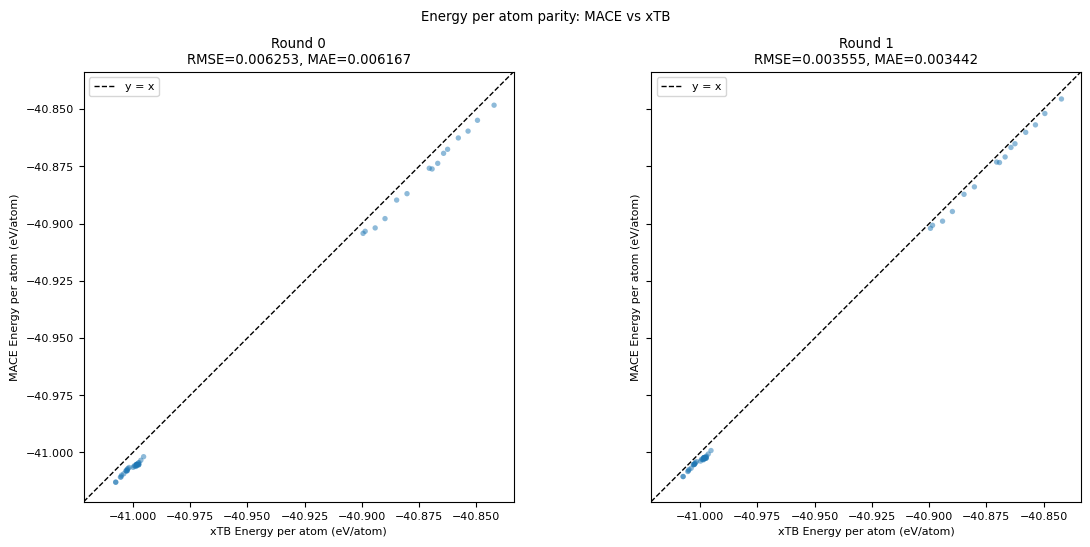

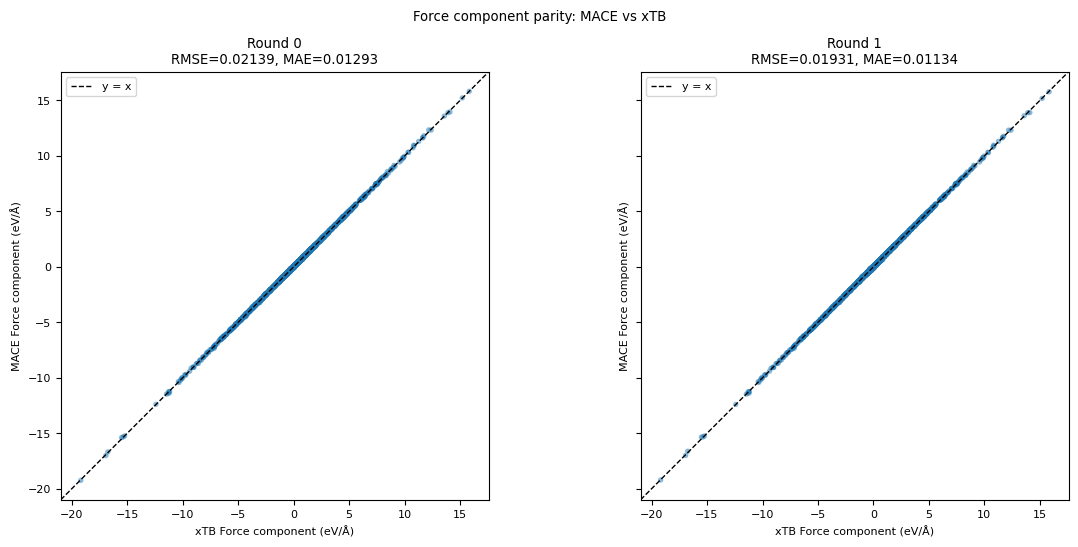

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/parity_plots"

df_energy = pd.read_csv(f"{OUTPUT_DIR}/energy_parity_data.csv")
df_forces = pd.read_csv(f"{OUTPUT_DIR}/force_parity_data.csv")
metrics_df = pd.read_csv(f"{OUTPUT_DIR}/parity_metrics.csv")


def get_metric(round_name, metric_name):
    row = metrics_df[(metrics_df["round"] == round_name) & (metrics_df["metric"] == metric_name)]
    return row["value"].values[0]


def make_parity_plot(true, pred_r0, pred_r1, label, units, filename,
                      rmse_r0, mae_r0, rmse_r1, mae_r1):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharex=True, sharey=True)

    lo = min(true.min(), pred_r0.min(), pred_r1.min())
    hi = max(true.max(), pred_r0.max(), pred_r1.max())
    pad = 0.05 * (hi - lo) if hi > lo else 1.0
    lims = (lo - pad, hi + pad)

    for ax, pred, title, rmse, mae in zip(
        axes,
        [pred_r0, pred_r1],
        ["Round 0", "Round 1"],
        [rmse_r0, rmse_r1],
        [mae_r0, mae_r1],
    ):
        ax.scatter(true, pred, alpha=0.5, s=15, edgecolors="none", color="tab:blue")
        ax.plot(lims, lims, "k--", linewidth=1, label="y = x")
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel(f"xTB {label} ({units})")
        ax.set_ylabel(f"MACE {label} ({units})")
        ax.set_title(f"{title}\nRMSE={rmse:.4g}, MAE={mae:.4g}")
        ax.legend(loc="upper left", fontsize=8)

    fig.suptitle(f"{label} parity: MACE vs xTB")
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{filename}", dpi=300, bbox_inches="tight")
    plt.show()


# ---- Energy parity ----
make_parity_plot(
    df_energy["xtb_energy_per_atom"].values,
    df_energy["mace_r0_energy_per_atom"].values,
    df_energy["mace_r1_energy_per_atom"].values,
    label="Energy per atom", units="eV/atom",
    filename="parity_energy_per_atom.png",
    rmse_r0=get_metric("round0", "energy_per_atom_rmse"),
    mae_r0=get_metric("round0", "energy_per_atom_mae"),
    rmse_r1=get_metric("round1", "energy_per_atom_rmse"),
    mae_r1=get_metric("round1", "energy_per_atom_mae"),
)

# ---- Force parity ----
make_parity_plot(
    df_forces["xtb_force"].values,
    df_forces["mace_r0_force"].values,
    df_forces["mace_r1_force"].values,
    label="Force component", units="eV/Å",
    filename="parity_forces.png",
    rmse_r0=get_metric("round0", "force_rmse"),
    mae_r0=get_metric("round0", "force_mae"),
    rmse_r1=get_metric("round1", "force_rmse"),
    mae_r1=get_metric("round1", "force_mae"),
)

## comparing committee for uncertainity across original valid.xyz, GB round0, GB round1

        set         metric     mean   median      std      min      max   n
      valid     std_energy 0.156411 0.156765 0.004698 0.144160 0.176004  45
      valid     mean_force 0.660617 0.171607 0.704131 0.150585 1.997552  45
      valid mean_std_force 0.001637 0.001124 0.000850 0.000832 0.004022  45
     a90_r0     std_energy 0.256091 0.255489 0.029484 0.173614 0.362335 500
     a90_r0     mean_force 0.673173 0.675294 0.049743 0.534624 0.897355 500
     a90_r0 mean_std_force 0.013673 0.013441 0.001596 0.010287 0.019700 500
     a90_r1     std_energy 0.155827 0.156356 0.002156 0.141862 0.160032 500
     a90_r1     mean_force 0.675477 0.677621 0.049853 0.536884 0.899229 500
     a90_r1 mean_std_force 0.001647 0.001644 0.000119 0.001360 0.002056 500
     b45_r0     std_energy 0.251695 0.253206 0.028665 0.169204 0.353428 500
     b45_r0     mean_force 0.684841 0.683845 0.052584 0.506955 0.848902 500
     b45_r0 mean_std_force 0.013887 0.013714 0.001741 0.009546 0.020400 500
     b45_r1 

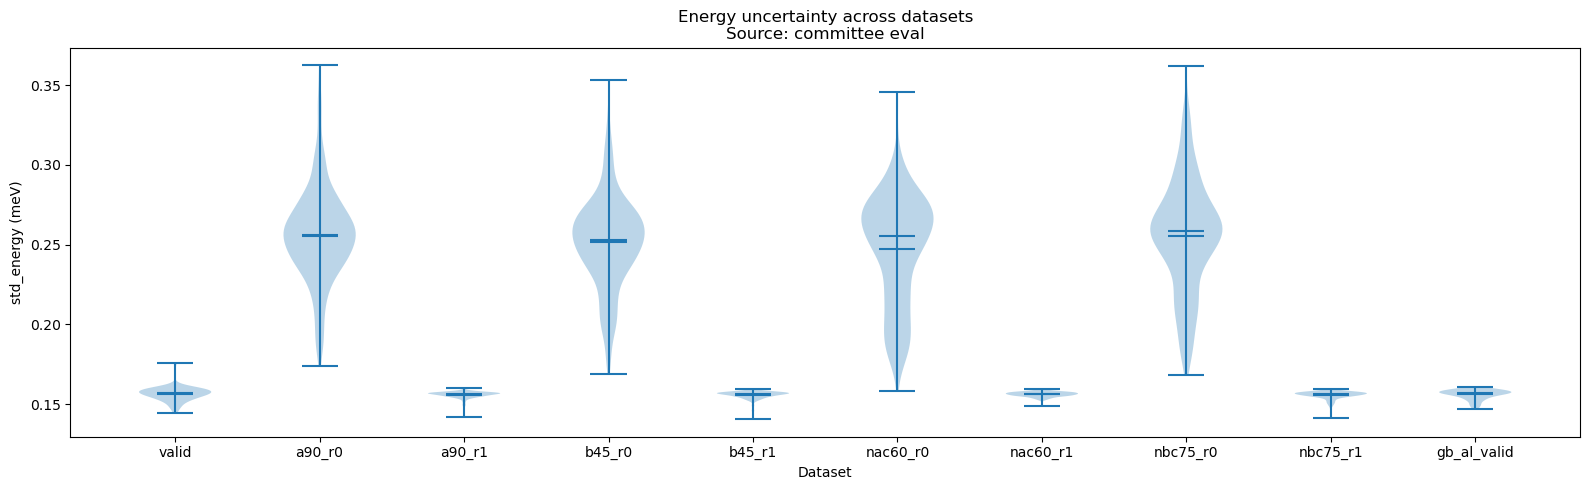

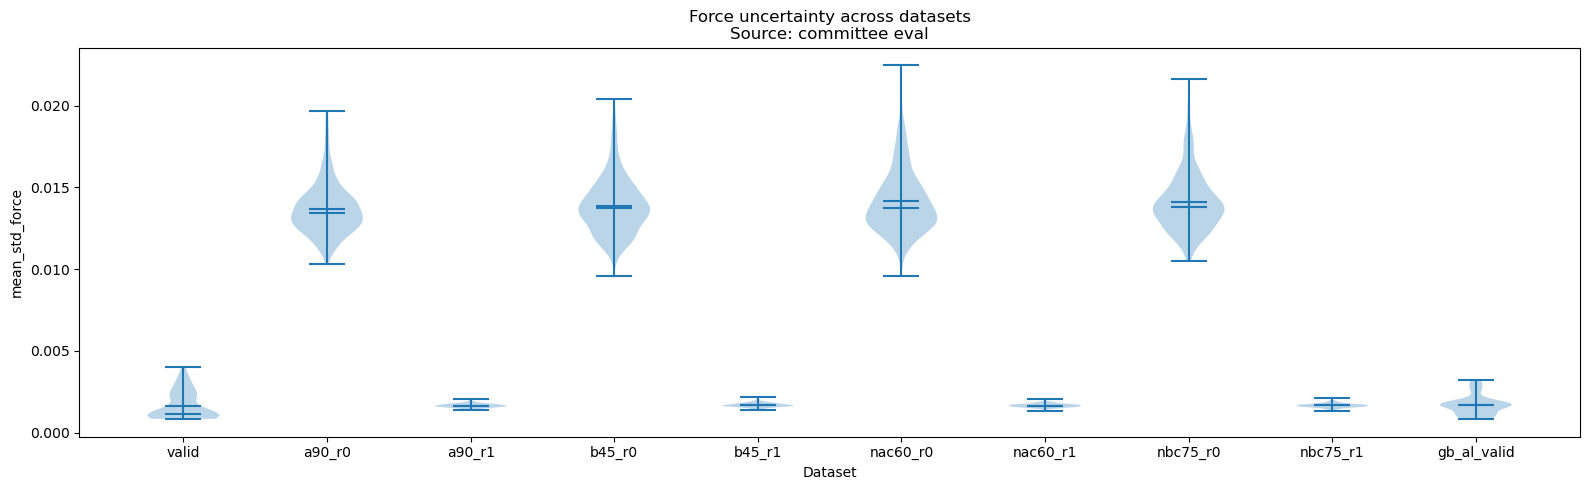

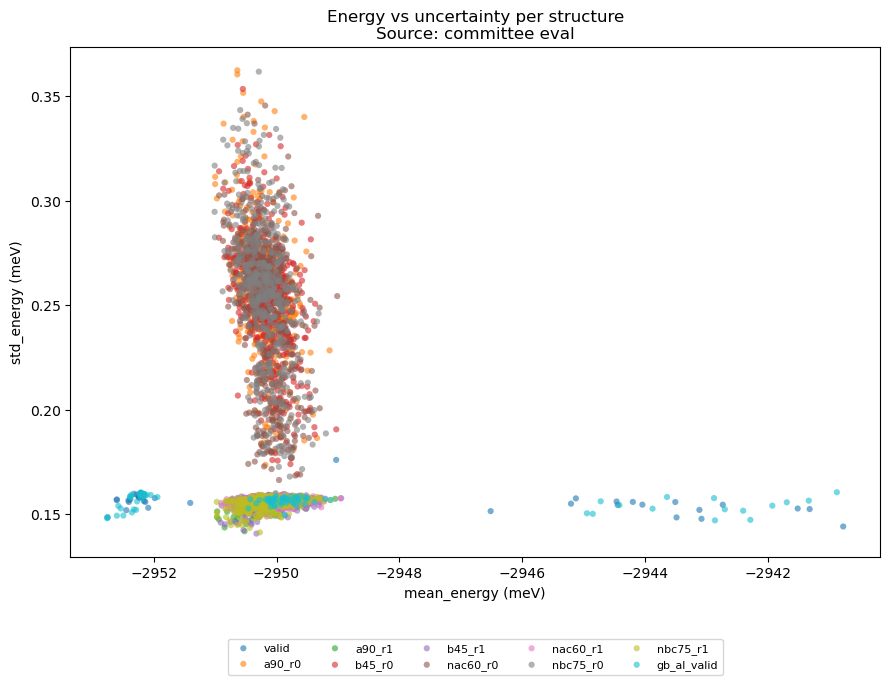

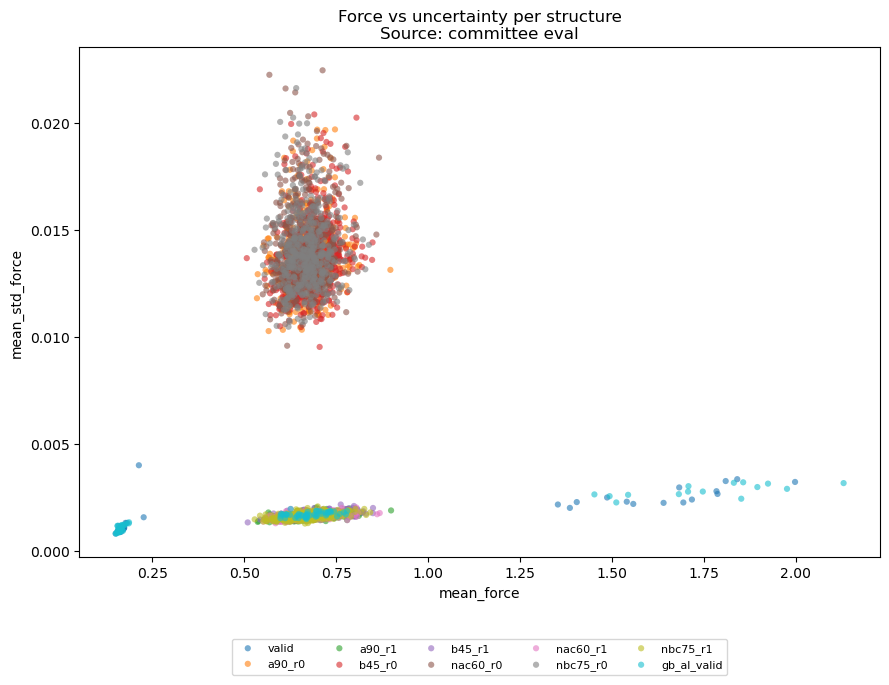


All CSVs and plots written to /home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/comparison_valid_a90_b45_nac60_nbc75_gb_al_valid


In [14]:
import json
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

DATASETS = [
    ("valid", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/valid_stats_r1.json"),

    ("a90_r0", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/a90_gb_subset500_stats.json"),
    ("a90_r1", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/a90_gb_subset500_stats_r1.json"),

    ("b45_r0", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/b45_gb_subset500_stats.json"),
    ("b45_r1", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/b45_gb_subset500_stats_r1.json"),

    ("nac60_r0", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/nac60_gb_subset500_stats.json"),
    ("nac60_r1", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/nac60_gb_subset500_stats_r1.json"),

    ("nbc75_r0", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/nbc75_gb_subset500_stats.json"),
    ("nbc75_r1", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/nbc75_gb_subset500_stats_r1.json"),

    ("gb_al_valid", "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/gb_al_valid_stats_r1.json"),
]
OUTPUT_DIR = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/comparison_valid_a90_b45_nac60_nbc75_gb_al_valid"

os.makedirs(OUTPUT_DIR, exist_ok=True)

dfs = []
for label, path in DATASETS:
    with open(path) as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    df["set"] = label
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv(f"{OUTPUT_DIR}/combined_committee_stats.csv", index=False)

# ---- 1. Summary statistics ----
summary_rows = []
for label, df in zip([d[0] for d in DATASETS], dfs):
    for col in ["std_energy", "mean_force", "mean_std_force"]:
        vals = df[col].values
        summary_rows.append({
            "set": label, "metric": col,
            "mean": np.mean(vals), "median": np.median(vals),
            "std": np.std(vals), "min": np.min(vals), "max": np.max(vals),
            "n": len(vals),
        })
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f"{OUTPUT_DIR}/summary_stats.csv", index=False)
print(df_summary.to_string(index=False))

labels = [d[0] for d in DATASETS]
positions = list(range(1, len(labels) + 1))
colors = plt.cm.tab10(np.linspace(0, 1, len(labels)))


def make_violin(column, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(6 + len(labels), 5))
    ax.violinplot([df[column] for df in dfs], showmeans=True, showmedians=True)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Dataset")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{filename}", dpi=300)
    plt.show()


make_violin("std_energy", "std_energy (meV)",
            "Energy uncertainty across datasets\nSource: committee eval",
            "violin_std_energy.png")

make_violin("mean_std_force", "mean_std_force",
            "Force uncertainty across datasets\nSource: committee eval",
            "violin_mean_std_force.png")


def make_scatter(x_col, y_col, xlabel, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    for label, df, c in zip(labels, dfs, colors):
        ax.scatter(df[x_col], df[y_col], label=label, alpha=0.6, s=20,
                   color=c, edgecolors="none")

    ax.ticklabel_format(useOffset=False, style="plain", axis="both")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=8)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/{filename}", dpi=300, bbox_inches="tight")
    plt.show()


make_scatter("mean_energy", "std_energy", "mean_energy (meV)", "std_energy (meV)",
             "Energy vs uncertainty per structure\nSource: committee eval",
             "scatter_mean_energy_vs_std_energy.png")

make_scatter("mean_force", "mean_std_force", "mean_force", "mean_std_force",
             "Force vs uncertainty per structure\nSource: committee eval",
             "scatter_mean_force_vs_mean_std_force.png")

print("\nAll CSVs and plots written to", OUTPUT_DIR)

In [ ]:
## combining xyz files
from ase.io import read, write

seed = read("/home/sgarg/git-repo/pentacene-gb-active-learning/data/labeled_data/train.xyz", index=":")
gb_al = read("/home/sgarg/git-repo/pentacene-gb-active-learning/data/labeled_data/gb_al_round1_labeled.xyz", index=":")

combined = seed + gb_al
write("/home/sgarg/git-repo/pentacene-gb-active-learning/data/labeled_data/gb_seed_al_round1.xyz", combined)
print(f"Seed: {len(seed)}, GB AL round1: {len(gb_al)}, Combined: {len(combined)}")

## Comparing uncertainity calculated from committee in energies and forces on valid.xyz and a90_gb_subset500.xyz dataset

In [1]:
import time

t0 = time.time()
import json
print("json import:", time.time() - t0)

t0 = time.time()
import pandas as pd
print("pandas import:", time.time() - t0)

t0 = time.time()
import plotly.graph_objects as go
print("plotly import:", time.time() - t0)

t0 = time.time()
with open("/home/sgarg/git-repo/pentacene-gb-active-learning/output/committee_v1/a90_gb_subset500_stats.json") as f:
    data = json.load(f)
print("json load:", time.time() - t0, "| n_entries:", len(data))

json import: 8.296966552734375e-05
pandas import: 0.351254940032959
plotly import: 0.0037224292755126953
json load: 0.0021533966064453125 | n_entries: 500


In [9]:
import json
import numpy as np
import pandas as pd
import os

# ============ PLACEHOLDERS: update these paths ============
VALID_JSON_PATH = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/valid_stats_r1.json"
GB_JSON_PATH = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/gb_al_valid_stats_r1.json"
GB_LABEL = "valid_gb_r1_subset500"
OUTPUT_DIR = "/home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/comparison_valid_gb_valid"
# ============================================================

os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(VALID_JSON_PATH) as f:
    valid_data = json.load(f)
with open(GB_JSON_PATH) as f:
    gb_data = json.load(f)

df_valid = pd.DataFrame(valid_data)
df_valid["set"] = "valid"
df_gb = pd.DataFrame(gb_data)
df_gb["set"] = GB_LABEL

df_all = pd.concat([df_valid, df_gb], ignore_index=True)
df_all.to_csv(f"{OUTPUT_DIR}/combined_committee_stats.csv", index=False)

# ---- 1. Summary statistics ----
summary_rows = []
for set_name, df in [("valid", df_valid), (GB_LABEL, df_gb)]:
    for col in ["std_energy", "mean_force", "mean_std_force"]:
        vals = df[col].values
        summary_rows.append({
            "set": set_name, "metric": col,
            "mean": np.mean(vals), "median": np.median(vals),
            "std": np.std(vals), "min": np.min(vals), "max": np.max(vals),
            "n": len(vals),
        })
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(f"{OUTPUT_DIR}/summary_stats.csv", index=False)
print(df_summary.to_string(index=False))

print(" CSVs written to", OUTPUT_DIR)

                  set         metric     mean   median      std      min      max  n
                valid     std_energy 0.156411 0.156765 0.004698 0.144160 0.176004 45
                valid     mean_force 0.660617 0.171607 0.704131 0.150585 1.997552 45
                valid mean_std_force 0.001637 0.001124 0.000850 0.000832 0.004022 45
valid_gb_r1_subset500     std_energy 0.156091 0.156929 0.003113 0.147090 0.160534 98
valid_gb_r1_subset500     mean_force 0.680892 0.660520 0.517124 0.150586 2.129563 98
valid_gb_r1_subset500 mean_std_force 0.001687 0.001683 0.000596 0.000832 0.003226 98
 CSVs written to /home/sgarg/git-repo/pentacene-gb-active-learning/output/gb_al_committee_v1/comparison_valid_gb_valid


## Plotting

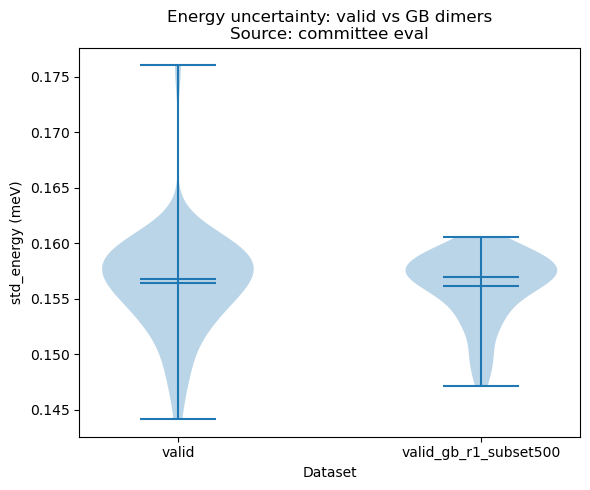

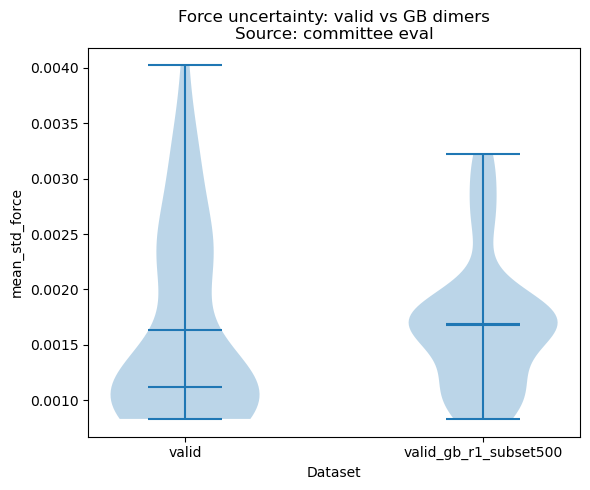

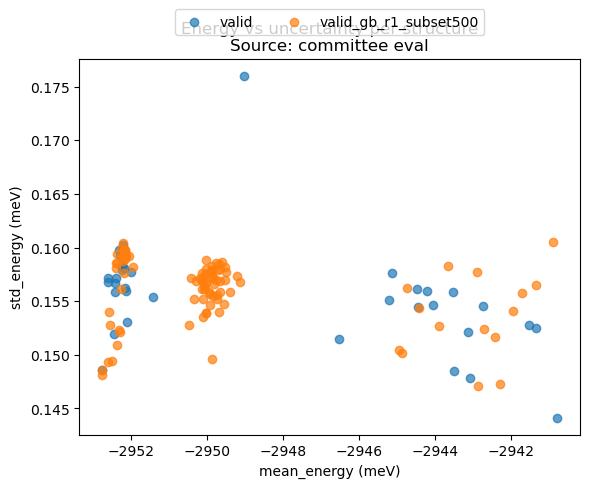

In [10]:
import matplotlib.pyplot as plt

# ---- 2. Violin: std_energy ----
fig1, ax1 = plt.subplots(figsize=(6, 5))
ax1.violinplot([df_valid["std_energy"], df_gb["std_energy"]],
               showmeans=True, showmedians=True)
ax1.set_xticks([1, 2])
ax1.set_xticklabels(["valid", GB_LABEL])
ax1.set_ylabel("std_energy (meV)")
ax1.set_xlabel("Dataset")
ax1.set_title("Energy uncertainty: valid vs GB dimers\nSource: committee eval")
fig1.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/violin_std_energy.png", dpi=300)
plt.show()

# ---- 3. Violin: mean_std_force ----
fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.violinplot([df_valid["mean_std_force"], df_gb["mean_std_force"]],
               showmeans=True, showmedians=True)
ax2.set_xticks([1, 2])
ax2.set_xticklabels(["valid", GB_LABEL])
ax2.set_ylabel("mean_std_force")
ax2.set_xlabel("Dataset")
ax2.set_title("Force uncertainty: valid vs GB dimers\nSource: committee eval")
fig2.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/violin_mean_std_force.png", dpi=300)
plt.show()

# ---- 4. Scatter: mean_energy vs std_energy ----
fig3, ax3 = plt.subplots(figsize=(6, 5))
ax3.scatter(df_valid["mean_energy"], df_valid["std_energy"], label="valid", alpha=0.7)
ax3.scatter(df_gb["mean_energy"], df_gb["std_energy"], label=GB_LABEL, alpha=0.7)
ax3.set_xlabel("mean_energy (meV)")
ax3.set_ylabel("std_energy (meV)")
ax3.set_title("Energy vs uncertainty per structure\nSource: committee eval")
ax3.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=2)
fig3.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/scatter_mean_energy_vs_std_energy.png", dpi=300)
plt.show()

## checking a,b,c vectors of pentacene bulk unit cell to confirm rotation axes and plane normals

In [ ]:

from ase.io import read

bulk = read("/Users/sonaligarg/Desktop/Phd_data/git-repo/pentacene-gb-active-learning/data/seed_structures/pentacene_bulk.cif")
cell = bulk.get_cell()

print("a_vec:", cell[0])
print("b_vec:", cell[1])
print("c_vec:", cell[2])

a_vec: [6.2753 0.     0.    ]
b_vec: [0.73611863 7.67859621 0.        ]
c_vec: [ 0.50126143  3.27683285 14.05681405]


/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/io/cif.py:411: UserWarning: crystal system 'triclinic' is not interpreted for space group Spacegroup(2, setting=1). This may result in wrong setting!
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 9 and 36 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 0 and 37 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 1 and 38 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/envs/pentacene-al/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:484: UserWarning: scaled_positions 2 and 39 are equivalent
  warnings.warn(
/Users/sonaligarg/miniconda3/

## Check whether Jitter is applied or not
- real thermal vibrational amplitudes in organic crystals at room temperature are typically in the 0.05-0.15 Å range
- so applying jitter which is bond length alteration

In [6]:
from ase.io import read
import numpy as np

jittered = read("/Users/sonaligarg/Desktop/Phd_data/git-repo/pentacene-gb-active-learning/data/seed_structures/generated_dimers/dimer_a_axis_000deg_sep4.20_jitter_0002.xyz")

positions = jittered.get_positions()[:36]
symbols = jittered.get_chemical_symbols()[:36]

cc_bonds = []
ch_bonds = []

for i in range(36):
    for j in range(i+1, 36):
        d = np.linalg.norm(positions[i] - positions[j])
        pair = {symbols[i], symbols[j]}
        if pair == {"C"} and d < 1.6:
            cc_bonds.append(d)
        elif pair == {"C", "H"} and d < 1.2:
            ch_bonds.append(d)

cc_bonds = np.array(cc_bonds)
ch_bonds = np.array(ch_bonds)

print("C-C bonds found:", len(cc_bonds), "| mean:", cc_bonds.mean(), "| std:", cc_bonds.std())
print("C-H bonds found:", len(ch_bonds), "| mean:", ch_bonds.mean(), "| std:", ch_bonds.std())

C-C bonds found: 26 | mean: 1.4238521480120407 | std: 0.06758463289763844
C-H bonds found: 14 | mean: 1.0666350629605106 | std: 0.05243517862081512
